In [1]:
%pip install ipykernel 


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [15]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field
import time

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_ollama import ChatOllama, OllamaEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

True

In [16]:
docs = (
     PyPDFLoader("data/Company_Policies.pdf").load()
    + PyPDFLoader("data/Company_Profile.pdf").load()
    + PyPDFLoader("data/Product_and_Pricing.pdf").load())

In [17]:

chunks = RecursiveCharacterTextSplitter(
    chunk_size=600, chunk_overlap=150
).split_documents(docs)


print(chunks)

[Document(metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2026-02-14T13:07:17+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-02-14T13:07:17+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': 'data/Company_Policies.pdf', 'total_pages': 2, 'page': 0, 'page_label': '1'}, page_content='NexaAI Solutions – Company Policies\nHR Policies\nNexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.\nAll employment decisions are made without discrimination.\n\x7f\nEqual opportunity employer\n\x7f\nBi-annual performance reviews\n\x7f\nClear career progression framework\n\x7f\nStrict anti-harassment policy\nLeave Policy\nEmployees are encouraged to maintain a healthy work-life balance.\n\x7f\nAnnual Leave: 18 working days per year\n\x7f\nSick Leave: 10 working days per year\n\x7f\nCasual Leave: 6 working days per year\n\x7f\nMaternity Leave: As per 

In [18]:
embedding=OllamaEmbeddings(model="nomic-embed-text:latest")

vector_store=FAISS.from_documents(embedding=embedding,documents=chunks)
reteriver=vector_store.as_retriever(search_kwargs={"k":5})
print(reteriver)


tags=['FAISS', 'OllamaEmbeddings'] vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x12d37ded0> search_kwargs={'k': 5}


In [19]:
llm=ChatOllama(model="qwen3:8b")

print(llm)

model='qwen3:8b'


In [20]:
class State(TypedDict):
    question: str
    need_retrieval: bool

    docs: List[Document]
    relevant_docs: List[Document]     

    context: str # New
    answer: str

In [22]:
class RetrieveDecision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description="True if external documents are needed to answer reliably, else False."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)


# IMPORTANT: no `.content` for structured output
should_retrieve_llm = llm.with_structured_output(RetrieveDecision)

def decide_retrieval(state: "State"):
    decision: RetrieveDecision = should_retrieve_llm.invoke(
        decide_retrieval_prompt.format_messages(question=state["question"])
    )
    return {"need_retrieval": decision.should_retrieve}

In [ ]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)


def generate_direct(state: State):
    out = llm.invoke(
        direct_generation_prompt.format_messages(
            question=state["question"]
        )
    )
    return {
        "answer": out.content
    }


def retrieve(state: State):
    return {"docs": reteriver.invoke(state["question"])}

In [24]:
class RelevanceDecision(BaseModel):
    is_relevant: bool = Field(
        ...,
        description="True if the document helps answer the question, else False."
    )

is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging document relevance.\n"
            "Return JSON that matches this schema:\n"
            "{{'is_relevant': boolean}}\n\n"
            "A document is relevant if it contains information useful for answering the question."
        ),
        (
            "human",
            "Question:\n{question}\n\nDocument:\n{document}"
        ),
    ]
)

relevance_llm = llm.with_structured_output(RelevanceDecision)

def is_relevant(state: State):
    
    relevant_docs: List[Document] = []

    for doc in state["docs"]:
        decision: RelevanceDecision = relevance_llm.invoke(
            is_relevant_prompt.format_messages(
                question=state["question"],
                document=doc.page_content
            )
        )

        if decision.is_relevant:
            relevant_docs.append(doc)

    return {"relevant_docs": relevant_docs}

In [25]:
Rag_generation_prompt=ChatPromptTemplate.from_messages(
    [
        ("system",
         "you are business Rag assistant.\n"
         "answer the user question using only the context provided"
         "if the context does not content any information answer i do not have the information"),
         ("human",
          "Question:{question}\n\n"
          "Context:{context}")
    ]
)

def generate_context_from_doc(state:State):
    context="\n\n--\n\n".join(
        [context.page_content for context in state.get("relevant_docs",[])]
    ).strip()

    if not context:
        return {"asnwer":"do not have the relevant context for the question"}
    result=llm.invoke(Rag_generation_prompt.format_prompt(
        question=state["question"],
        context=context
    ))

    return {
        "answer":result.content,"context":context
    }

In [26]:
def no_relevant_docs(state: State):
    return {"answer": "No relevant document found.", "context": ""}

In [27]:
def route_after_decide(state: State) -> Literal["generate_direct", "retrieve"]:
    if state["need_retrieval"]:
        return "retrieve"
    return "generate_direct"

In [29]:
def route_after_relevance(state: State) -> Literal["generate_context_from_doc", "no_relevant_docs"]:
    if state.get("relevant_docs") and len(state["relevant_docs"]) > 0:
        return "generate_context_from_doc"
    return "no_relevant_docs"

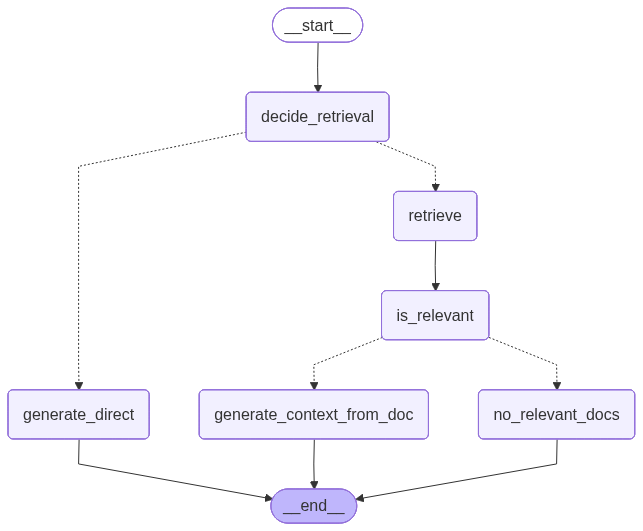

In [32]:
G=StateGraph(State)
G.add_node("decide_retrieval",decide_retrieval)
G.add_node("generate_direct",generate_direct)
G.add_node("retrieve",retrieve)
G.add_node("is_relevant",is_relevant)
G.add_node("generate_context_from_doc",generate_context_from_doc)
G.add_node("no_relevant_docs",no_relevant_docs)
G.add_edge(START,"decide_retrieval")
G.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {
        "generate_direct":"generate_direct",
        "retrieve":"retrieve"
    },
)
G.add_edge("generate_direct",END)
G.add_edge("retrieve","is_relevant")


G.add_conditional_edges(
    "is_relevant",
    route_after_relevance,
    {
       "generate_context_from_doc":"generate_context_from_doc",
        "no_relevant_docs":"no_relevant_docs"
    },
)

G.add_edge("generate_context_from_doc",END)
G.add_edge("no_relevant_docs",END)

App=G.compile()
App



In [34]:
App.invoke(
    {
       "question":"what is the leave policy of NexaAI?" ,
       "need_retrieval":True,
       
       
    }
)

: 

In [ ]:
#supported loop to check the correctnes of the answer produced by the llm 

In [1]:
%pip install langchain-groq


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [44]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_ollama import ChatOllama ,OllamaEmbeddings
from langchain_groq import ChatGroq
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
import os
load_dotenv()

True

In [45]:
groq_chat_model=ChatGroq(streaming=True,model="llama-3.3-70b-versatile",temperature=0.0,max_retries=2,timeout=10,api_key=os.getenv("GROQ_API_KEY"),verbose=True)
print(groq_chat_model)

profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True} client=<groq.resources.chat.completions.Completions object at 0x1363896f0> async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x1363892a0> model_name='llama-3.3-70b-versatile' temperature=1e-08 model_kwargs={} groq_api_key=SecretStr('**********') request_timeout=10.0 streaming=True


In [46]:
docs = (
     PyPDFLoader("data/Company_Policies.pdf").load()
    + PyPDFLoader("data/Company_Profile.pdf").load()
    + PyPDFLoader("data/Product_and_Pricing.pdf").load())

In [47]:
i=0
while True:
    for doc in docs:
        i+=1
        print(f"count:{i}")
        print(doc.page_content)
    break

count:1
NexaAI Solutions – Company Policies
HR Policies
NexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.
All employment decisions are made without discrimination.

Equal opportunity employer

Bi-annual performance reviews

Clear career progression framework

Strict anti-harassment policy
Leave Policy
Employees are encouraged to maintain a healthy work-life balance.

Annual Leave: 18 working days per year

Sick Leave: 10 working days per year

Casual Leave: 6 working days per year

Maternity Leave: As per statutory norms

Unused annual leave may be carried forward up to 30 days
Workplace Conduct
Employees are expected to act professionally and ethically at all times.

Maintain confidentiality of company and client information

Avoid conflicts of interest

No acceptance of bribes or unethical gifts

Compliance with information security policies
Disciplinary Actions
Any violation of company policies may result in disciplinary action.
cou

In [48]:
chunks=RecursiveCharacterTextSplitter(chunk_size=600, chunk_overlap=150).split_documents(docs)

In [50]:
embedding=OllamaEmbeddings(model="nomic-embed-text:latest")
vector_store=FAISS.from_documents(embedding=embedding, documents=chunks)
print(vector_store)

retriver=vector_store.as_retriever(search_kwargs={"k":4})


In [51]:
#graph State
class State(TypedDict):
    question:str
    eed_retrieval: bool
    docs: List[Document]
    relevant_docs: List[Document]
    context: str
    answer: str
    # Post-generation verification
    issupp: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: List[str]

    retries: int

    isuse: Literal["useful", "not_useful"]
    use_reason: str

    

In [52]:
class RetrieveDecision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description="True if external documents are needed to answer reliably, else False."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON with key: should_retrieve (boolean).\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts from company documents.\n"
            "- should_retrieve=False for general explanations/definitions.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)

should_retrieve_llm = groq_chat_model.with_structured_output(RetrieveDecision)

def decide_retrieval(state: State):
    decision: RetrieveDecision = should_retrieve_llm.invoke(
        decide_retrieval_prompt.format_messages(question=state["question"])
    )
    return {"need_retrieval": decision.should_retrieve}

def route_after_decide(state: State) -> Literal["generate_direct", "retrieve"]:
    return ["retrieve" if state.get("need_retrieval") else "generate_direct"]

In [53]:

direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer using only your general knowledge.\n"
            "If it requires specific company info, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)

def generate_direct(state: State):
    out = groq_chat_model.invoke(direct_generation_prompt.format_messages(question=state["question"]))
    return {"answer": out.content}

In [54]:

def retrieve(state: State):
    return {"docs": retriver.invoke(state["question"])}


In [55]:

class RelevanceDecision(BaseModel):
    is_relevant: bool = Field(
        ...,
        description="True ONLY if the document contains info that can directly answer the question."
    )

is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging document relevance at a TOPIC level.\n"
            "Return JSON matching the schema.\n\n"
            "A document is relevant if it discusses the same entity or topic area as the question.\n"
            "It does NOT need to contain the exact answer.\n\n"
            "Examples:\n"
            "- HR policies are relevant to questions about notice period, probation, termination, benefits.\n"
            "- Pricing documents are relevant to questions about refunds, trials, billing terms.\n"
            "- Company profile is relevant to questions about leadership, culture, size, or strategy.\n\n"
            "Do NOT decide whether the document fully answers the question.\n"
            "That will be checked later by IsSUP.\n"
            "When unsure, return is_relevant=true."
        ),
        ("human", "Question:\n{question}\n\nDocument:\n{document}"),
    ]
)


relevance_llm = groq_chat_model.with_structured_output(RelevanceDecision)

def is_relevant(state: State):
    relevant_docs: List[Document] = []
    for doc in state.get("docs", []):
        decision: RelevanceDecision = relevance_llm.invoke(
            is_relevant_prompt.format_messages(
                question=state["question"],
                document=doc.page_content,
            )
        )
        if decision.is_relevant:
            relevant_docs.append(doc)
    return {"relevant_docs": relevant_docs}

def route_after_relevance(state: State) -> Literal["generate_from_context", "no_answer_found"]:
    if state.get("relevant_docs") and len(state["relevant_docs"]) > 0:
        return "generate_from_context"
    return "no_answer_found"

In [56]:

rag_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a business rag chatbot.\n\n"
            "You will receive a CONTEXT block from internal company documents.\n"
            "Task:\n"
            "Answer the question based on the context"
            "Dont mention that you are getting a context in your answer"
        ),
        ("human", "Question:\n{question}\n\nContext:\n{context}"),
    ]
)

def generate_from_context(state: State):
    context = "\n\n---\n\n".join([d.page_content for d in state.get("relevant_docs", [])]).strip()
    if not context:
        return {"answer": "No answer found.", "context": ""}
    out = groq_chat_model.invoke(
        rag_generation_prompt.format_messages(question=state["question"], context=context)
    )
    return {"answer": out.content, "context": context}

def no_answer_found(state: State):
    return {"answer": "No answer found.", "context": ""}

In [57]:
class Issupp(BaseModel):
    issupp:Literal["fully_supported", "partially_supported", "no_support"]
    evidance:List[str]=Field(default_factory=list)


issupp_prompt=ChatPromptTemplate.from_messages(
    [
        ("system",
         
         "You are verifying whether the ANSWER is supported by the CONTEXT.\n"
            "Return JSON with keys: issup, evidence.\n"
            "issup must be one of: fully_supported, partially_supported, no_support.\n\n"
            "How to decide issup:\n"
            "- fully_supported:\n"
            "  Every meaningful claim is explicitly supported by CONTEXT, and the ANSWER does NOT introduce\n"
            "  any qualitative/interpretive words that are not present in CONTEXT.\n"
            "  (Examples of disallowed words unless present in CONTEXT: culture, generous, robust, designed to,\n"
            "  supports professional development, best-in-class, employee-first, etc.)\n\n"
            "- partially_supported:\n"
            "  The core facts are supported, BUT the ANSWER includes ANY abstraction, interpretation, or qualitative\n"
            "  phrasing not explicitly stated in CONTEXT (e.g., calling policies 'culture', saying leave is 'generous',\n"
            "  or inferring outcomes like 'supports professional development').\n\n"
            "- no_support:\n"
            "  The key claims are not supported by CONTEXT.\n\n"
            "Rules:\n"
            "- Be strict: if you see ANY unsupported qualitative/interpretive phrasing, choose partially_supported.\n"
            "- If the answer is mostly unrelated to the question or unsupported, choose no_support.\n"
            "- Evidence: include up to 3 short direct quotes from CONTEXT that support the supported parts.\n"
            "- Do not use outside knowledge."
         
         ),
         ("human",
          "Question:\n{question}\n\n"
            "Answer:\n{answer}\n\n"
            "Context:\n{context}\n"
          )
    ]
)



with_supp_llm=groq_chat_model.with_structured_output(Issupp)

def is_supp(state:State):
    decision:Issupp=with_supp_llm.invoke(
        issupp_prompt.from_messages(
            question=state["question"],
            answer=state.get("answer",""),
            context=state.get("context","")
        )
    )
    return {"issupp":decision.issupp,"evidance":decision.evidance}



max_retries=10

def route_after_issupp(state:State)->Literal["accept_answer", "revise_answer"]:
    if state.get("issupp") == "fully_supported":
        return "accept_answer"

    if state.get("retries", 0) >= max_retries:
        return "accept_answer" 
    return "revise_answer"





In [58]:
def accept_answer(state:State):
    return {}


In [59]:

revise_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a STRICT reviser.\n\n"
            "You must output based on the following format:\n\n"
            "FORMAT (quote-only answer):\n"
            "- <direct quote from the CONTEXT>\n"
            "- <direct quote from the CONTEXT>\n\n"
            "Rules:\n"
            "- Use ONLY the CONTEXT.\n"
            "- Do NOT add any new words besides bullet dashes and the quotes themselves.\n"
            "- Do NOT explain anything.\n"
            "- Do NOT say 'context', 'not mentioned', 'does not mention', 'not provided', etc.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Current Answer:\n{answer}\n\n"
            "CONTEXT:\n{context}"
        ),
    ]
)



def revise_answer(state: State):
    out = groq_chat_model.invoke(
        revise_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer", ""),
            context=state.get("context", ""),
        )
    )
    return {
        "answer": out.content,
        "retries": state.get("retries", 0) + 1,
    }

In [60]:

class IsUSEDecision(BaseModel):
    isuse: Literal["useful", "not_useful"]
    reason: str = Field(..., description="Short reason in 1 line.")

isuse_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging USEFULNESS of the ANSWER for the QUESTION.\n\n"
            "Goal:\n"
            "- Decide if the answer actually addresses what the user asked.\n\n"
            "Return JSON with keys: isuse, reason.\n"
            "isuse must be one of: useful, not_useful.\n\n"
            "Rules:\n"
            "- useful: The answer directly answers the question or provides the requested specific info.\n"
            "- not_useful: The answer is generic, off-topic, or only gives related background without answering.\n"
            "- Do NOT use outside knowledge.\n"
            "- Do NOT re-check grounding (IsSUP already did that). Only check: 'Did we answer the question?'\n"
            "- Keep reason to 1 short line."
        ),
        (
            "human",
            "Question:\n{question}\n\nAnswer:\n{answer}"
        ),
    ]
)

isuse_llm = groq_chat_model.with_structured_output(IsUSEDecision)

def is_use(state: State):
    decision: IsUSEDecision = isuse_llm.invoke(
        isuse_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer", ""),
        )
    )
    return {"isuse": decision.isuse, "use_reason": decision.reason}


def route_after_isuse(state: State) -> Literal["END", "no_answer_found"]:
    if state.get("isuse") == "useful":
        return "END"
    return "no_answer_found"

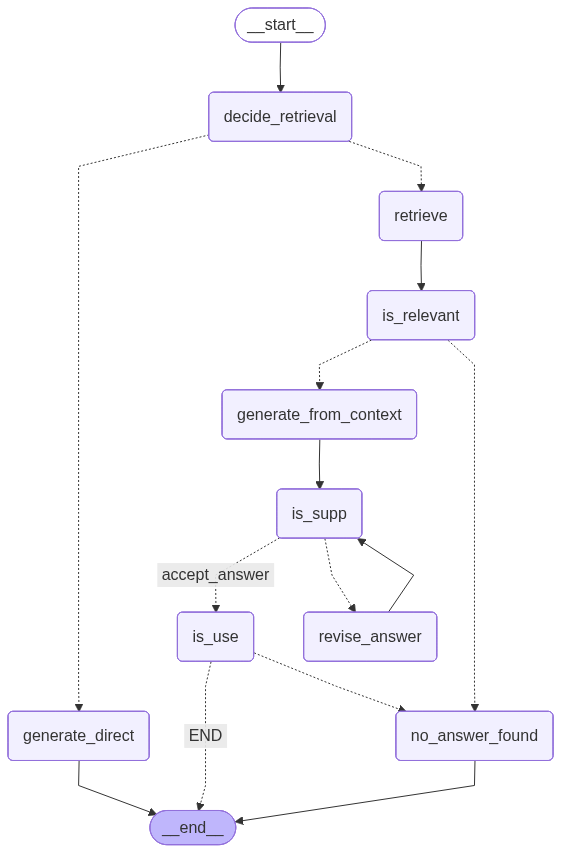

In [61]:
g = StateGraph(State)

g.add_node("decide_retrieval", decide_retrieval)
g.add_node("generate_direct", generate_direct)
g.add_node("retrieve", retrieve)

g.add_node("is_relevant", is_relevant)
g.add_node("generate_from_context", generate_from_context)
g.add_node("no_answer_found", no_answer_found)


g.add_node("is_supp", is_supp)
g.add_node("revise_answer", revise_answer)


g.add_node("is_use", is_use)



g.add_edge(START, "decide_retrieval")

g.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {"generate_direct": "generate_direct", "retrieve": "retrieve"},
)

g.add_edge("generate_direct", END)

g.add_edge("retrieve", "is_relevant")

g.add_conditional_edges(
    "is_relevant",
    route_after_relevance,
    {
        "generate_from_context": "generate_from_context",
        "no_answer_found": "no_answer_found",
    },
)


g.add_edge("no_answer_found", END)


g.add_edge("generate_from_context", "is_supp")

g.add_conditional_edges(
    "is_supp",
    route_after_issupp,
    {
        "accept_answer": "is_use",      
        "revise_answer": "revise_answer",
    },
)

g.add_edge("revise_answer", "is_supp")  
g.add_conditional_edges(
    "is_use",
    route_after_isuse,
    {
        "END": END,
        "no_answer_found": "no_answer_found",
    },
)

app = g.compile()
app

In [62]:
app.invoke(
   {
       "question":"who is the CEO of NExaAI solution",
       "eed_retrieval":True,
       "retries":2,
        "issup":["Full_supported"]
        
    }
)

{'question': 'who is the CEO of NExaAI solution',
 'eed_retrieval': True,
 'answer': "I don't know based on my general knowledge.",
 'retries': 2}

In [ ]:
#creating demo 
import os 
from groq import Groq

client=Groq(api_key=os.environ.get("GROQ_API_KEY"))
# print(os.environ.get("GROQ_API_KEY"))

speech_file_path="orpheus-english.wav"
model="canopylabs/orpheus-v1-english"
voice="troy"
text="Welcome to Orpheus text-to-speech. [cheerful] This is an example of high-quality English audio generation with vocal directions support."
response_format ="wav"

result=client.audio.speech.create(
model=model,
voice=voice,
input=text,
response_format=response_format,

)
result.write_to_file(file=speech_file_path)

 Welcome to Orpheus Text-to-Speech. This is an example of high-quality English audio generation with vocal direction support.
